# Figure 1: Plot Bathymetry on wedge map

This notebook produces a simple bathymetric Map of Fram Strait and parts of the Nordic Seas.

## Imports & Paths

In [ ]:
# General
import numpy as np
import xarray as xr
import sys

# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo
from matplotlib.font_manager import FontProperties

# Custom
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
import wedge_map as wm

%load_ext autoreload
%autoreload 2

font_bold_cond = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLDCOND.OTF' 
font_cond = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-COND.OTF' 
font_bold = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLD.OTF' 
font      = "/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-REGULAR.OTF"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plotpath   = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/paper/"
save_plots = False

In [3]:
# Load bathymetry data
ds_bath = xr.open_dataset("/albedo/work/user/quraus001/bath/ETOPO_2022_v1_60s_N90W180_bed.nc")
# select only reagion of interest
ds_bath = ds_bath.sel(lon=slice(-40, 40), lat=slice(65, 90))

# Load OSISAF sea ice data
ds_ice_seasonal = xr.open_dataset("/albedo/work/user/quraus001/FESOM_particles/result/processed_results/osisaf_seasmean_2006-2007.nc")


/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: The following kwargs were not used by contour: 'visible'
  result = super().contourf(*args, **kwargs)


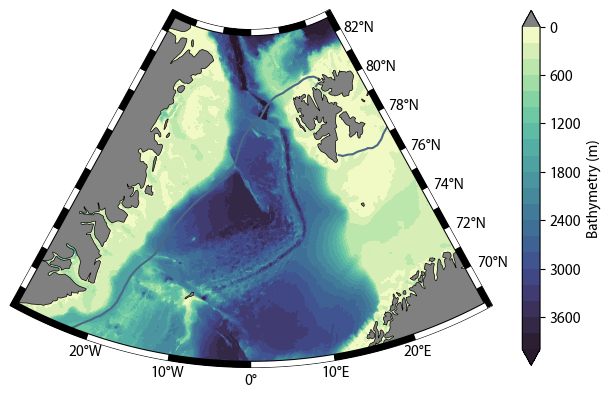

In [ ]:
fig, ax = wm.wedge_map_boudary(lon_min=-30, lon_max=30, lat_max=83, lat_min=68, figsize=(6,6))
wm.add_wedge_gridlines(ax, latitudes=np.arange(70,83, 2), lon_text_bottom=67.75, lat_text=31, show_left=False, show_top=False, lines=False, font_path=font, fontsize=11)
wm.add_zebra_boundary(ax, lat_max=83, lat_min=68, lon_min=-30, lon_max=30,latitudes=np.arange(69, 83), longitudes=np.arange(-40, 40, 10), zorder=100, n_interp=2000, corners=False)

# 1. Create your ACTUAL colormap (no set_under, so 0 is just the first color)
cmap_main = cmo.cm.deep.copy()

# 2. Create a PROXY colormap JUST for the colorbar
cmap_proxy = cmo.cm.deep.copy()
cmap_proxy.set_under('grey') 

# 3. Plot the actual data
# We start at 0 so land (0) gets the first color of 'deep'
levels = np.arange(-1, 4001, 200)

im = ax.contourf(
    ds_bath.lon, ds_bath.lat, ds_bath.z * -1,
    levels=levels,
    cmap=cmap_main,
    transform=ccrs.PlateCarree(),
    extend="both", # Only show the 'deep' arrow on the plot itself
    zorder=1
)

# Create an invisible proxy image for the colorbar (To get around the missmatch of ETOPO and cartopy land feature)
proxy = ax.contourf(
    [[0,0],[0,0]], [[0,0],[0,0]], [[-10,-10],[-10,-10]], # Fake data out of range
    levels=levels +1,
    cmap=cmap_proxy,
    extend="both",
    visible=False  # Keep it hidden
)


font_prop = FontProperties(fname=font)
fontsize = 11  
# Create the colorbar using the PROXY, not the IM
cbar = fig.colorbar(proxy, ax=ax, pad=0.03, shrink=0.6, extend="both")
cbar.set_label("Bathymetry (m)", fontproperties=font_prop, fontsize=fontsize)
cbar.ax.invert_yaxis()
for label in cbar.ax.get_yticklabels():
    label.set_fontproperties(font_prop)
    label.set_fontsize(fontsize)

ax.add_feature(cfeature.LAND, facecolor="grey", zorder=9, edgecolor="black", linewidth=0.5)

ax.contour(ds_ice_seasonal.lon.values, ds_ice_seasonal.lat.values, ds_ice_seasonal.ice_conc.mean(dim="time").values,
                levels=[15], colors=["#FFFFFF"], linewidths=1.5, #"#C8FAFF"
                transform=ccrs.PlateCarree(),#, zorder=4,
            )


if save_plots:
    plt.savefig(plotpath + "Fig1_map_bathy_ohne-grid_wide_ice.png", dpi=500)
